# Libraries

In [1]:
from experiments.plot_incremental_noise import load_results_multi_seed, plot_noise_vs_scores_multi_seed, \
                                                    compute_corrs_multi_seed, plot_corrs_multi_seed, \
                                                    save_results, split_coeur_results

In [2]:
import os
experiment_path = "experiments/"

In [16]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import pearsonr, spearmanr
import warnings

# O. Utils

In [4]:
def extract_exhaustiveness(dataset: str, experiment: str, 
                             exhaustiveness_level: str = "swise_coverage", exhaustiveness_type: str = "ROUGE-L Precision"):
    results = load_results_multi_seed(
        main_folder_path=os.path.join(experiment_path, "output", dataset),
        experiment_type=experiment
    )
    
    extract = []
    for seed in results:
        extract.append(seed[exhaustiveness_level][exhaustiveness_type].tolist())
    return np.array(extract)

def extract_cohesion(dataset: str, experiment: str, 
                             cohesion_model: str = "KMeans", cohesion_type: str = "Adjusted Mutual Info"):
    results = load_results_multi_seed(
        main_folder_path=os.path.join(experiment_path, "output", dataset),
        experiment_type=experiment
    )
    
    extract = []
    for seed in results:
        extract.append(seed["model_wise_coherence"][cohesion_model][cohesion_type].tolist())
    return np.array(extract)

def extract_qus(dataset: str, experiment: str):
    results = load_results_multi_seed(
        main_folder_path=os.path.join(experiment_path, "output", dataset),
        experiment_type=experiment
    )
    
    extract = []
    for seed in results:
        extract.append(seed["aqusa_scores"].tolist())
    return np.array(extract)

def extract_usqa(dataset: str, experiment: str):
    results = load_results_multi_seed(
        main_folder_path=os.path.join(experiment_path, "output", dataset),
        experiment_type=experiment
    )
    
    extract = []
    for seed in results:
        extract.append(seed["usqa_scores"].tolist())
    return np.array(extract)

def extract_actual_information_levels(dataset: str, experiment: str):
    results = load_results_multi_seed(
        main_folder_path=os.path.join(experiment_path, "output", dataset),
        experiment_type=experiment
    )
    extract = []
    for seed in results:
        if "epic" in experiment:
            extract.append(seed["actual_epic_information_levels"].tolist())
        elif "story" in experiment:
            extract.append(seed["actual_story_information_levels"].tolist())
        else:
            raise ValueError("Experiment name must contain 'epic' or 'story'")
    return np.array(extract)

def extract_information_levels(dataset: str, experiment: str):
    results = load_results_multi_seed(
        main_folder_path=os.path.join(experiment_path, "output", dataset),
        experiment_type=experiment
    )
    extract = results[0]["target_noise_levels"].copy()
    return 1 - np.array(extract)

def aggregate_seeds(data: np.ndarray):
    return {
        "mean": np.mean(data, axis=0),
        "std": np.std(data, axis=0)
    }

def coeur_score(exh: np.ndarray, coh: np.ndarray, lmbd: float = 0.5):
    return lmbd * exh + (1 - lmbd) * coh

def plot_final_results(noise_level: np.ndarray, exh: dict, coh: dict, qus: dict, usqa: dict, nse: dict, coe: dict):
    plt.figure(figsize=(10, 6))
    
    plt.plot(noise_level, nse["mean"][::-1], label='Actual Information Ratio', marker='o')
    plt.fill_between(noise_level, nse["mean"][::-1] - nse["std"][::-1], nse["mean"][::-1] + nse["std"][::-1], alpha=0.2)
    plt.plot(noise_level, qus["mean"][::-1], label='QUS Score', marker='o')
    plt.fill_between(noise_level, qus["mean"][::-1] - qus["std"][::-1], qus["mean"][::-1] + qus["std"][::-1], alpha=0.2)
    plt.plot(noise_level, usqa["mean"][::-1], label='USQA Score', marker='o')
    plt.fill_between(noise_level, usqa["mean"][::-1] - usqa["std"][::-1], usqa["mean"][::-1] + usqa["std"][::-1], alpha=0.2)
    plt.plot(noise_level, coe["mean"][::-1], label='COEUR Score', marker='o')
    plt.fill_between(noise_level, coe["mean"][::-1] - coe["std"][::-1], coe["mean"][::-1] + coe["std"][::-1], alpha=0.2)

    plt.xlabel('Noise Level')
    plt.ylabel('Scores')
    plt.title('Final Results across Noise Levels')
    plt.legend()
    plt.grid()
    plt.show()

def compute_final_coeur(dataset: str, experiment: str, lmbd: float = 0.5,
                        exhaustiveness_level: str = "swise_coverage", exhaustiveness_type: str = "ROUGE-L Precision",
                        cohesion_model: str = "KMeans", cohesion_type: str = "Adjusted Mutual Info"):
    exh = extract_exhaustiveness(
        dataset=dataset,
        experiment=experiment,
        exhaustiveness_level=exhaustiveness_level,
        exhaustiveness_type=exhaustiveness_type
    )
    coh = extract_cohesion(
        dataset=dataset,
        experiment=experiment,
        cohesion_model=cohesion_model,
        cohesion_type=cohesion_type
    )
    coe = coeur_score(exh, coh, lmbd=lmbd)
    return coe

def plot_COEUR_vs_QUS(dataset: str, experiment: str, lmbd: float = 0.5,
                      exhaustiveness_level: str = "swise_coverage", exhaustiveness_type: str = "ROUGE-L Precision",
                      cohesion_model: str = "KMeans", cohesion_type: str = "Adjusted Mutual Info"):
    exh = extract_exhaustiveness(
        dataset=dataset,
        experiment=experiment,
        exhaustiveness_level=exhaustiveness_level,
        exhaustiveness_type=exhaustiveness_type
    )
    coh = extract_cohesion(
        dataset=dataset,
        experiment=experiment,
        cohesion_model=cohesion_model,
        cohesion_type=cohesion_type
    )
    qus = extract_qus(
        dataset=dataset,
        experiment=experiment
    )
    usqa = extract_usqa(
        dataset=dataset,
        experiment=experiment
    )
    nse = extract_actual_information_levels(
        dataset=dataset,
        experiment=experiment
    )
    rnse = extract_information_levels(
        dataset=dataset,
        experiment=experiment
    )
    coe = coeur_score(exh, coh, lmbd=lmbd)
    agg_coe = aggregate_seeds(coe)
    agg_qus = aggregate_seeds(qus)
    agg_usqa = aggregate_seeds(usqa)
    agg_nse = aggregate_seeds(nse)

    plot_final_results(
        noise_level=rnse,
        exh=aggregate_seeds(exh),
        coh=aggregate_seeds(coh),
        qus=agg_qus,
        usqa=agg_usqa,
        nse=agg_nse,
        coe=agg_coe
    )

In [5]:
def compute_correlations(dataset: str, experiment: str, lmbd: float = 0.5,
                         exhaustiveness_level: str = "swise_coverage", exhaustiveness_type: str = "ROUGE-L Precision",
                         cohesion_model: str = "KMeans", cohesion_type: str = "Adjusted Mutual Info"):
    exh = extract_exhaustiveness(
        dataset=dataset,
        experiment=experiment,
        exhaustiveness_level=exhaustiveness_level,
        exhaustiveness_type=exhaustiveness_type
    )
    coh = extract_cohesion(
        dataset=dataset,
        experiment=experiment,
        cohesion_model=cohesion_model,
        cohesion_type=cohesion_type
    )
    qus = extract_qus(
        dataset=dataset,
        experiment=experiment
    )
    usqa = extract_usqa(
        dataset=dataset,
        experiment=experiment
    )
    coe = coeur_score(exh, coh, lmbd=lmbd)
    nse = extract_actual_information_levels(
        dataset=dataset,
        experiment=experiment
    )
    rnse = extract_information_levels(
        dataset=dataset,
        experiment=experiment
    )
    pearson_qus_list = []
    spearman_qus_list = []
    pearson_usqa_list = []
    spearman_usqa_list = []
    pearson_coh_list = []
    spearman_coh_list = []
    pearson_exh_list = []
    spearman_exh_list = []
    pearson_coe_list = []
    spearman_coe_list = []
    pearson_qus_pvalue_list = []
    spearman_qus_pvalue_list = []
    pearson_usqa_pvalue_list = []
    spearman_usqa_pvalue_list = []
    pearson_coh_pvalue_list = []
    spearman_coh_pvalue_list = []
    pearson_exh_pvalue_list = []
    spearman_exh_pvalue_list = []
    pearson_coe_pvalue_list = []
    spearman_coe_pvalue_list = []
    for i in range(len(nse)):
        pearson_qus, pearson_pvalue_qus = pearsonr(qus[i], nse[i])
        spearman_qus, spearman_pvalue_qus = spearmanr(qus[i], nse[i])
        pearson_usqa, pearson_pvalue_usqa = pearsonr(usqa[i], nse[i])
        spearman_usqa, spearman_pvalue_usqa = spearmanr(usqa[i], nse[i])
        pearson_coh, pearson_pvalue_coh = pearsonr(coh[i], nse[i])
        spearman_coh, spearman_pvalue_coh = spearmanr(coh[i], nse[i])
        pearson_exh, pearson_pvalue_exh = pearsonr(exh[i], nse[i])
        spearman_exh, spearman_pvalue_exh = spearmanr(exh[i], nse[i])
        pearson_coe, pearson_pvalue_coe = pearsonr(coe[i], nse[i])
        spearman_coe, spearman_pvalue_coe = spearmanr(coe[i], nse[i])
        pearson_qus_list.append(pearson_qus)
        spearman_qus_list.append(spearman_qus)
        pearson_usqa_list.append(pearson_usqa)
        spearman_usqa_list.append(spearman_usqa)
        pearson_coh_list.append(pearson_coh)
        spearman_coh_list.append(spearman_coh)
        pearson_exh_list.append(pearson_exh)
        spearman_exh_list.append(spearman_exh)
        pearson_coe_list.append(pearson_coe)
        spearman_coe_list.append(spearman_coe)
        pearson_qus_pvalue_list.append(pearson_pvalue_qus)
        spearman_qus_pvalue_list.append(spearman_pvalue_qus)
        pearson_usqa_pvalue_list.append(pearson_pvalue_usqa)
        spearman_usqa_pvalue_list.append(spearman_pvalue_usqa)
        pearson_coh_pvalue_list.append(pearson_pvalue_coh)
        spearman_coh_pvalue_list.append(spearman_pvalue_coh)
        pearson_exh_pvalue_list.append(pearson_pvalue_exh)
        spearman_exh_pvalue_list.append(spearman_pvalue_exh)
        pearson_coe_pvalue_list.append(pearson_pvalue_coe)
        spearman_coe_pvalue_list.append(spearman_pvalue_coe)
    
    #return a dataframe with the results
    df = pd.DataFrame({
        "Seed": [i + 1 for i in range(len(nse))],
        "QUS - Pearson": pearson_qus_list,
        "QUS - Spearman": spearman_qus_list,
        "USQA - Pearson": pearson_usqa_list,
        "USQA - Spearman": spearman_usqa_list,
        "COH - Pearson": pearson_coh_list,
        "COH - Spearman": spearman_coh_list,
        "EXH - Pearson": pearson_exh_list,
        "EXH - Spearman": spearman_exh_list,
        "COEUR - Pearson": pearson_coe_list,
        "COEUR - Spearman": spearman_coe_list,
        "QUS - Pearson p-value": pearson_qus_pvalue_list,
        "QUS - Spearman p-value": spearman_qus_pvalue_list,
        "USQA - Pearson p-value": pearson_usqa_pvalue_list,
        "USQA - Spearman p-value": spearman_usqa_pvalue_list,
        "COH - Pearson p-value": pearson_coh_pvalue_list,
        "COH - Spearman p-value": spearman_coh_pvalue_list,
        "EXH - Pearson p-value": pearson_exh_pvalue_list,
        "EXH - Spearman p-value": spearman_exh_pvalue_list,
        "COEUR - Pearson p-value": pearson_coe_pvalue_list,
        "COEUR - Spearman p-value": spearman_coe_pvalue_list
    })
    return df

def plot_correlations(df, alpha=0.05):
    """
    Plot Pearson and Spearman correlations for QUS and COEUR scores.
    Expects output from compute_correlations function.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with columns for Pearson/Spearman correlations and p-values
    alpha : float
        Significance level for p-values (default: 0.05)
    """
    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    
    # Extract mean and std for correlations
    pearson_qus_mean = df["QUS - Pearson"].mean()
    pearson_qus_std = df["QUS - Pearson"].std()
    pearson_usqa_mean = df["USQA - Pearson"].mean()
    pearson_usqa_std = df["USQA - Pearson"].std()
    pearson_coeur_mean = df["COEUR - Pearson"].mean()
    pearson_coeur_std = df["COEUR - Pearson"].std()
    
    spearman_qus_mean = df["QUS - Spearman"].mean()
    spearman_qus_std = df["QUS - Spearman"].std()
    spearman_usqa_mean = df["USQA - Spearman"].mean()
    spearman_usqa_std = df["USQA - Spearman"].std()
    spearman_coeur_mean = df["COEUR - Spearman"].mean()
    spearman_coeur_std = df["COEUR - Spearman"].std()
    
    # Extract mean p-values for coloring
    pearson_qus_pvalue = df["QUS - Pearson p-value"].mean()
    pearson_usqa_pvalue = df["USQA - Pearson p-value"].mean()
    pearson_coeur_pvalue = df["COEUR - Pearson p-value"].mean()
    spearman_qus_pvalue = df["QUS - Spearman p-value"].mean()
    spearman_usqa_pvalue = df["USQA - Spearman p-value"].mean()
    spearman_coeur_pvalue = df["COEUR - Spearman p-value"].mean()
    
    # Pearson subplot
    metrics = ["QUS", "USQA", "COEUR"]
    means_p = [pearson_qus_mean, pearson_usqa_mean, pearson_coeur_mean]
    stds_p = [pearson_qus_std, pearson_usqa_std, pearson_coeur_std]
    pvalues_p = [pearson_qus_pvalue, pearson_usqa_pvalue, pearson_coeur_pvalue]
    
    colors_p = ["green" if pval < alpha else "red" for pval in pvalues_p]
    x = np.arange(len(metrics))
    
    ax1.bar(x, means_p, yerr=stds_p, color=colors_p, alpha=0.7, capsize=5)
    ax1.set_xticks(x)
    ax1.set_xticklabels(metrics)
    ax1.set_ylabel("Pearson Correlation Coefficient (r)")
    ax1.set_title(f"Mean ± Std Pearson Correlation Coefficients (alpha={alpha})")
    ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax1.grid(True, alpha=0.3)
    
    # Spearman subplot
    means_s = [spearman_qus_mean, spearman_usqa_mean, spearman_coeur_mean]
    stds_s = [spearman_qus_std, spearman_usqa_std, spearman_coeur_std]
    pvalues_s = [spearman_qus_pvalue, spearman_usqa_pvalue, spearman_coeur_pvalue]

    colors_s = ["green" if pval < alpha else "red" for pval in pvalues_s]
    
    ax2.bar(x, means_s, yerr=stds_s, color=colors_s, alpha=0.7, capsize=5)
    ax2.set_xticks(x)
    ax2.set_xticklabels(metrics)
    ax2.set_ylabel("Spearman Correlation Coefficient (ρ)")
    ax2.set_title(f"Mean ± Std Spearman Correlation Coefficients (alpha={alpha})")
    ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [6]:
def display_correlation_summary(dataset: str, experiment: str, 
                                exhaustiveness_level: str = "swise_coverage", exhaustiveness_type: str = "ROUGE-2 Precision",
                                cohesion_model: str = "AgglomerativeClustering", cohesion_type: str = "Adjusted Mutual Info",
                                lmbd: float = 0.5):
    corrs = compute_correlations(
        dataset=dataset,
        experiment=experiment,
        exhaustiveness_level=exhaustiveness_level,
        exhaustiveness_type=exhaustiveness_type,
        cohesion_model=cohesion_model,
        cohesion_type=cohesion_type,
        lmbd=lmbd
    ).fillna(0)
    corrs_display = corrs.drop(columns=["Seed"], inplace=False)
    means = corrs_display.mean()
    stds = corrs_display.std()
    concat = pd.concat([means, stds], axis=1)
    concat.columns = ['Mean', 'Std']
    split_index = concat.index.str.split(' - ', expand=True)
    concat.index = pd.MultiIndex.from_tuples(
        split_index, names=['Metric', 'Statistic']
    )
    pivot_df = concat.pivot_table(index='Metric', columns='Statistic', values=['Mean', 'Std'])
    result = pd.DataFrame({
        col: pivot_df["Mean"][col].map("{:.2f}".format) + " ± " + pivot_df["Std"][col].map("{:.2f}".format)
        for col in pivot_df["Mean"].columns
    })
    result = result[["Pearson", "Spearman", "Pearson p-value", "Spearman p-value"]]
    return result

# I. Retro

### 1. Exhaustiveness Noise

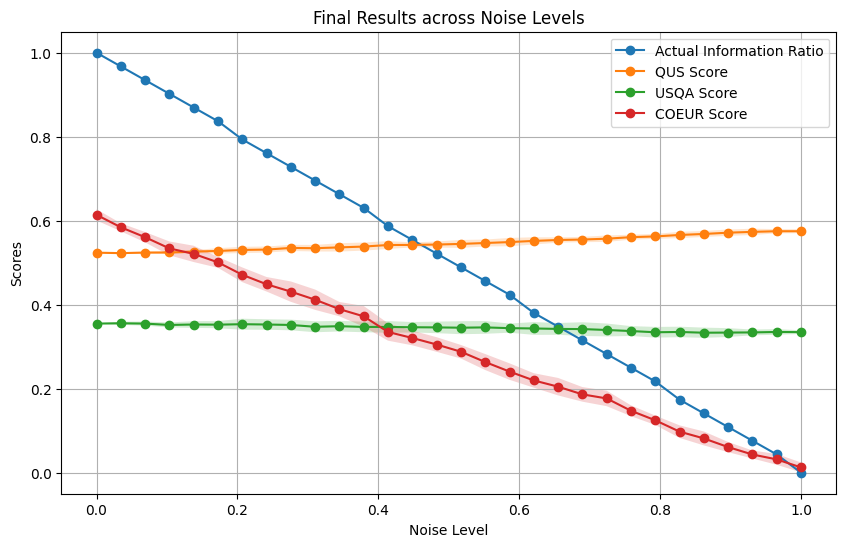

In [13]:
plot_COEUR_vs_QUS(
    dataset="retro",
    experiment="epic/set_9_paper_results",
    exhaustiveness_level="swise_coverage",
    exhaustiveness_type="ROUGE-2 Precision",
    cohesion_model="SpectralClustering",
    cohesion_type="Adjusted Mutual Info",
    lmbd=0.5
)

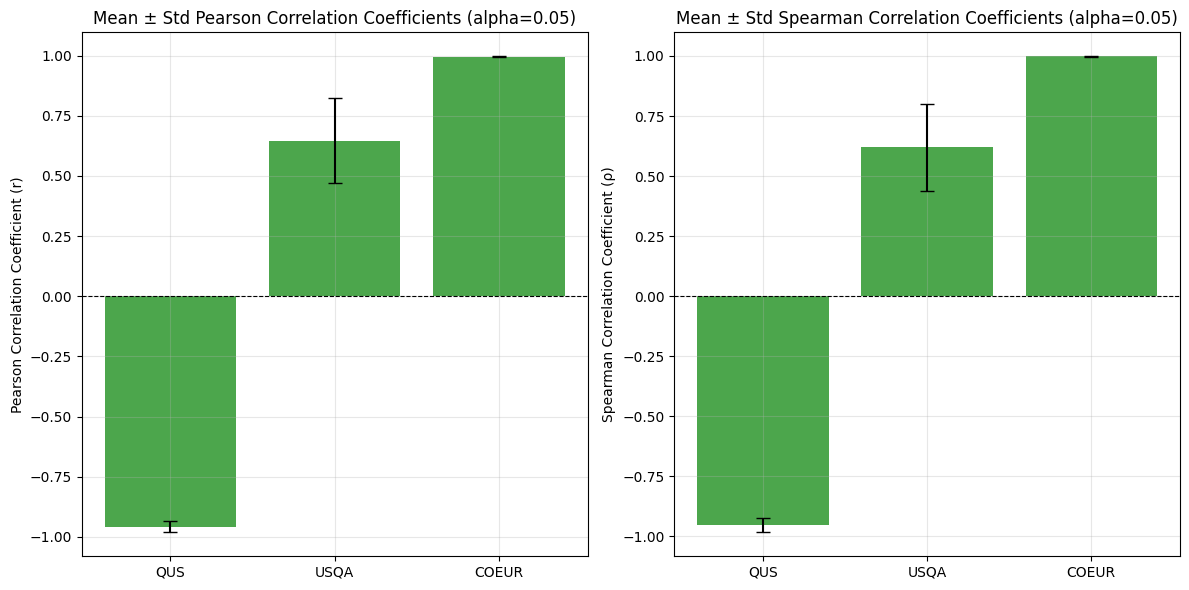

In [12]:
corrs = compute_correlations(
    dataset="retro",
    experiment="epic/set_9_paper_results",
    exhaustiveness_level="swise_coverage",
    exhaustiveness_type="ROUGE-2 Precision",
    cohesion_model="SpectralClustering",
    cohesion_type="Adjusted Mutual Info",
    lmbd=0.5
)

plot_correlations(corrs, alpha=0.05)

In [11]:
display_correlation_summary(
    dataset="retro",
    experiment="epic/set_9_paper_results",
    exhaustiveness_level="swise_coverage",
    exhaustiveness_type="ROUGE-2 Precision",
    cohesion_model="SpectralClustering",
    cohesion_type="Adjusted Mutual Info",
    lmbd=0.5
)

,Pearson,Spearman,Pearson p-value,Spearman p-value
Metric,,,,
COEUR,1.00 ± 0.00,1.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00
COH,0.88 ± 0.07,0.88 ± 0.08,0.00 ± 0.00,0.00 ± 0.00
EXH,1.00 ± 0.00,1.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00
QUS,-0.96 ± 0.02,-0.96 ± 0.03,0.00 ± 0.00,0.00 ± 0.00
USQA,0.65 ± 0.18,0.62 ± 0.18,0.01 ± 0.03,0.02 ± 0.03


### 2. Cohesion Noise 

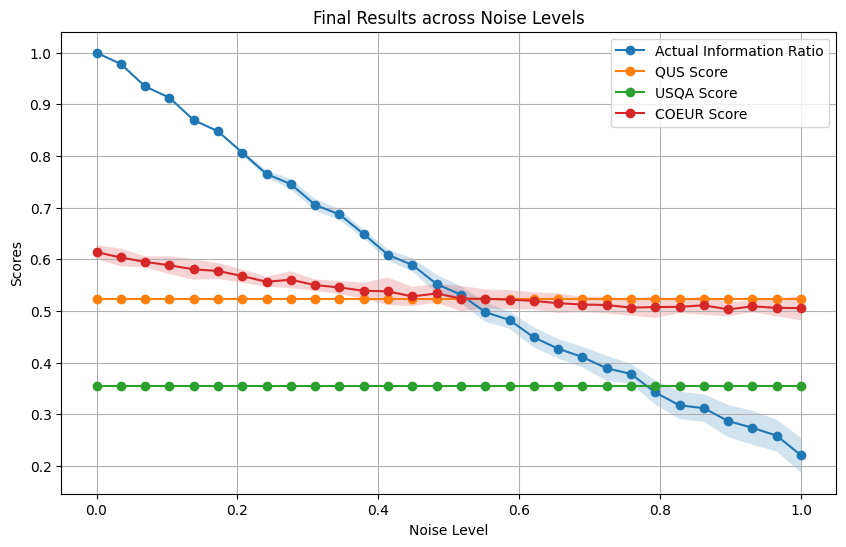

In [10]:
plot_COEUR_vs_QUS(
    dataset="retro",
    experiment="story/set_9_paper_results",
    exhaustiveness_level="swise_coverage",
    exhaustiveness_type="ROUGE-2 Precision",
    cohesion_model="SpectralClustering",
    cohesion_type="Adjusted Mutual Info",
    lmbd=0.5
)

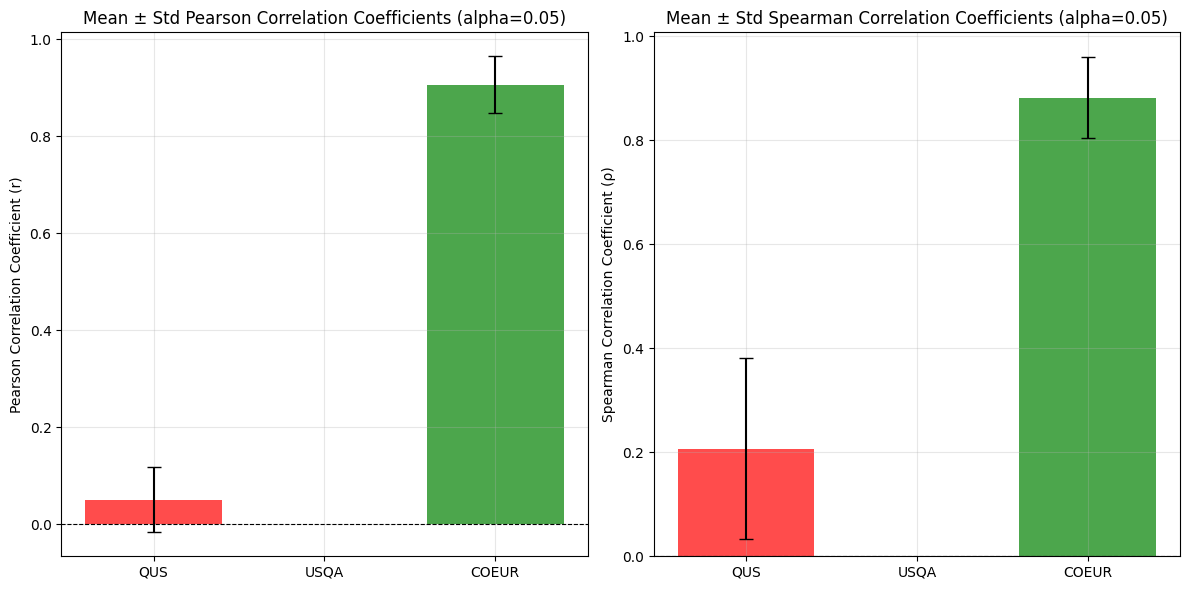

In [ ]:
corrs = compute_correlations(
    dataset="retro",
    experiment="story/set_9_paper_results",
    exhaustiveness_level="swise_coverage",
    exhaustiveness_type="ROUGE-2 Precision",
    cohesion_model="SpectralClustering",
    cohesion_type="Adjusted Mutual Info",
    lmbd=0.5
)
plot_correlations(corrs, alpha=0.05)

In [17]:
warnings.filterwarnings("ignore")
display_correlation_summary(
    dataset="retro",
    experiment="story/set_9_paper_results",
    exhaustiveness_level="swise_coverage",
    exhaustiveness_type="ROUGE-2 Precision",
    cohesion_model="AgglomerativeClustering",
    cohesion_type="Adjusted Mutual Info",
    lmbd=0.5
)

,Pearson,Spearman,Pearson p-value,Spearman p-value
Metric,,,,
COEUR,0.98 ± 0.01,0.97 ± 0.01,0.00 ± 0.00,0.00 ± 0.00
COH,0.98 ± 0.01,0.97 ± 0.01,0.00 ± 0.00,0.00 ± 0.00
EXH,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00
QUS,0.04 ± 0.06,0.15 ± 0.17,0.52 ± 0.39,0.23 ± 0.28
USQA,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00


# II. Trident

### 1. Exhaustiveness Noise

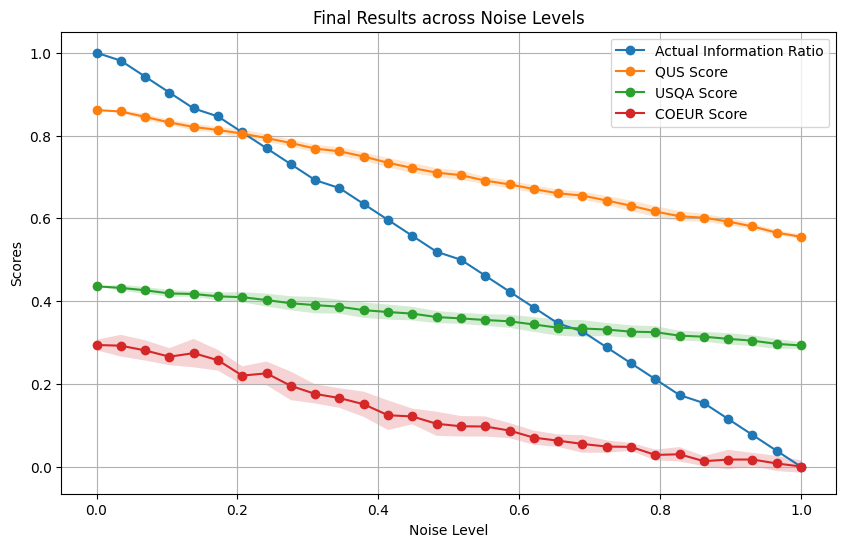

In [43]:
plot_COEUR_vs_QUS(
    dataset="trident",
    experiment="epic",
    exhaustiveness_level="swise_coverage",
    exhaustiveness_type="ROUGE-2 Precision",
    cohesion_model="SpectralClustering",
    cohesion_type="Adjusted Mutual Info",
    lmbd=0.5
)

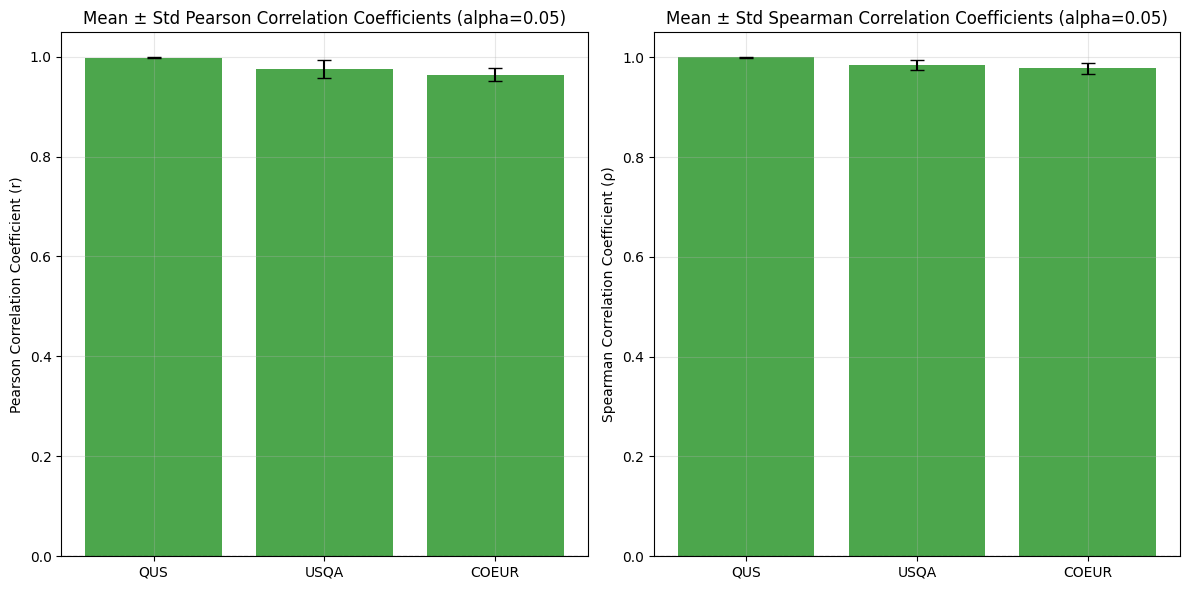

In [46]:
corrs = compute_correlations(
    dataset="trident",
    experiment="epic",
    exhaustiveness_level="swise_coverage",
    exhaustiveness_type="ROUGE-2 Precision",
    cohesion_model="SpectralClustering",
    cohesion_type="Adjusted Mutual Info",
    lmbd=0.5
)
plot_correlations(corrs, alpha=0.05)

In [63]:
display_correlation_summary(
    dataset="trident",
    experiment="epic",
    exhaustiveness_level="swise_coverage",
    exhaustiveness_type="ROUGE-2 Precision",
    cohesion_model="SpectralClustering",
    cohesion_type="Adjusted Mutual Info",
    lmbd=0.5
)

,Pearson,Spearman,Pearson p-value,Spearman p-value
Metric,,,,
COEUR,0.96 ± 0.01,0.98 ± 0.01,0.00 ± 0.00,0.00 ± 0.00
COH,0.94 ± 0.02,0.94 ± 0.02,0.00 ± 0.00,0.00 ± 0.00
EXH,0.99 ± 0.00,1.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00
QUS,1.00 ± 0.00,1.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00
USQA,0.97 ± 0.02,0.98 ± 0.01,0.00 ± 0.00,0.00 ± 0.00


### 2. Cohesion Noise 

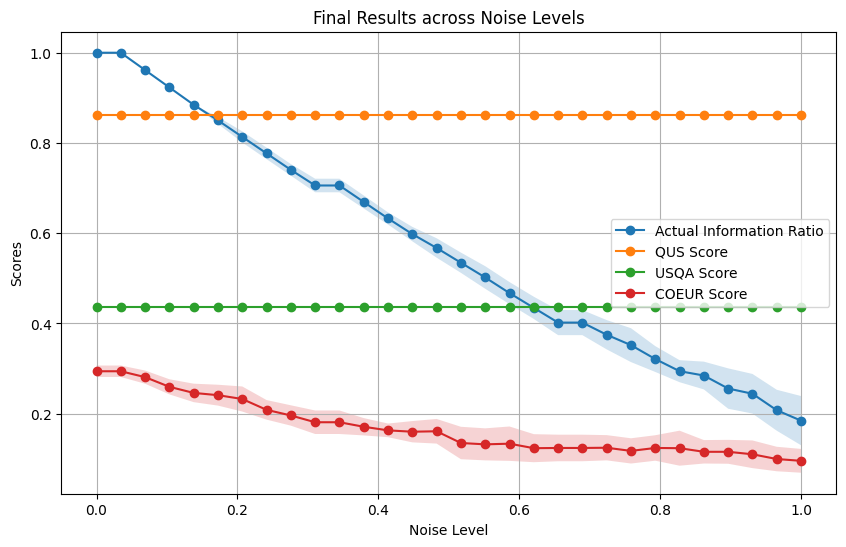

In [49]:
plot_COEUR_vs_QUS(
    dataset="trident",
    experiment="story",
    exhaustiveness_level="swise_coverage",
    exhaustiveness_type="ROUGE-2 Precision",
    cohesion_model="SpectralClustering",
    cohesion_type="Adjusted Mutual Info",
    lmbd=0.5
)

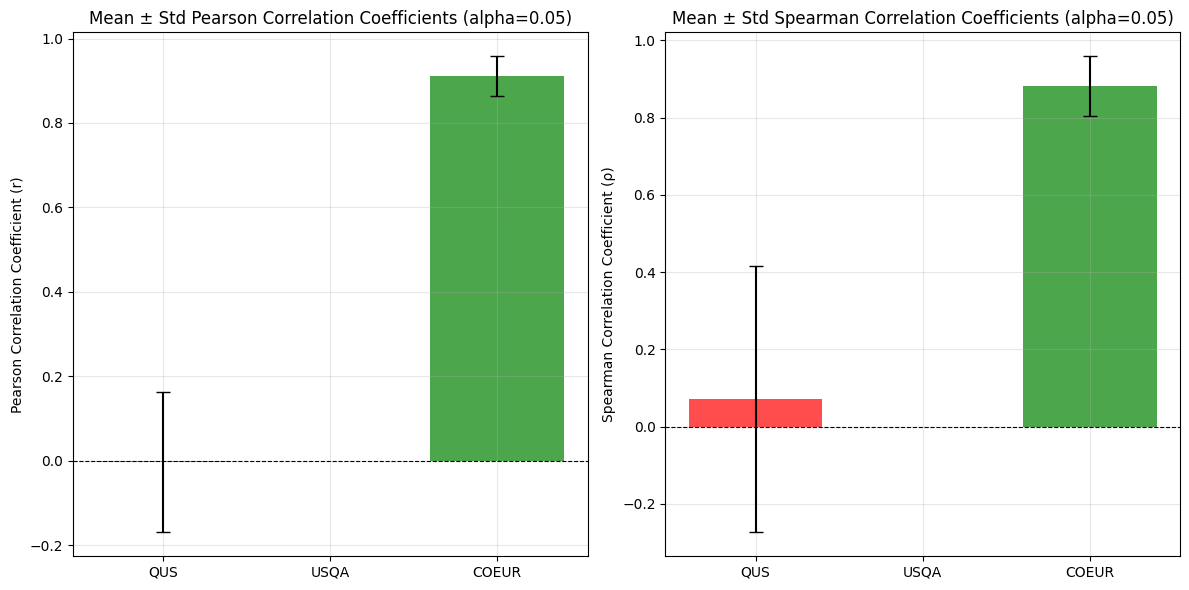

In [18]:
warnings.filterwarnings("ignore")
corrs = compute_correlations(
    dataset="trident",
    experiment="story/set_9_paper_results",
    exhaustiveness_level="swise_coverage",
    exhaustiveness_type="ROUGE-2 Precision",
    cohesion_model="SpectralClustering",
    cohesion_type="Adjusted Mutual Info",
    lmbd=0.5
)
plot_correlations(corrs, alpha=0.05)

In [19]:
warnings.filterwarnings("ignore")
display_correlation_summary(
    dataset="trident",
    experiment="story/set_9_paper_results",
    exhaustiveness_level="swise_coverage",
    exhaustiveness_type="ROUGE-2 Precision",
    cohesion_model="AgglomerativeClustering",
    cohesion_type="Adjusted Mutual Info",
    lmbd=0.5
)

,Pearson,Spearman,Pearson p-value,Spearman p-value
Metric,,,,
COEUR,0.95 ± 0.03,0.94 ± 0.05,0.00 ± 0.00,0.00 ± 0.00
COH,0.95 ± 0.03,0.94 ± 0.05,0.00 ± 0.00,0.00 ± 0.00
EXH,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00
QUS,-0.00 ± 0.17,0.07 ± 0.34,0.59 ± 0.29,0.25 ± 0.25
USQA,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00


# III. Alfred

### 1. Exhaustiveness Noise

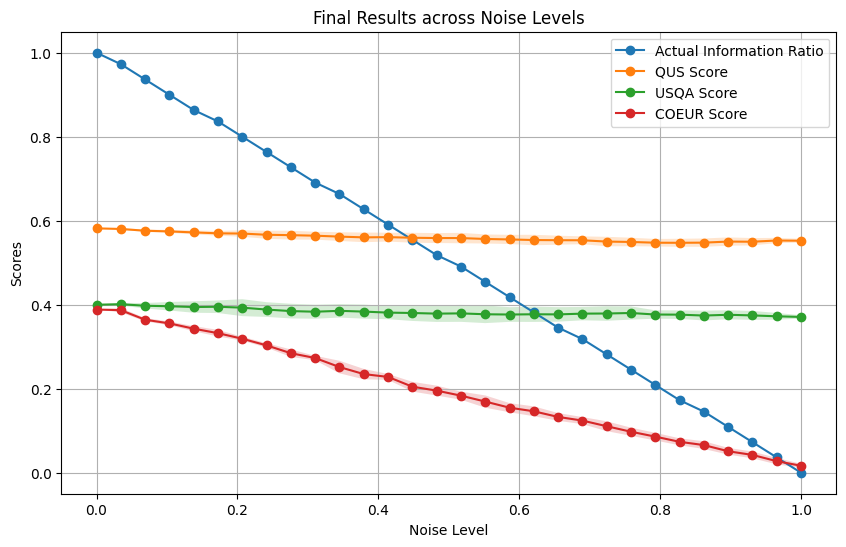

In [21]:
plot_COEUR_vs_QUS(
    dataset="alfred",
    experiment="epic",
    lmbd=0.75,
    exhaustiveness_level="swise_coverage",
    exhaustiveness_type="ROUGE-2 Precision",
    cohesion_model="AgglomerativeClustering",
    cohesion_type="Adjusted Mutual Info"
)

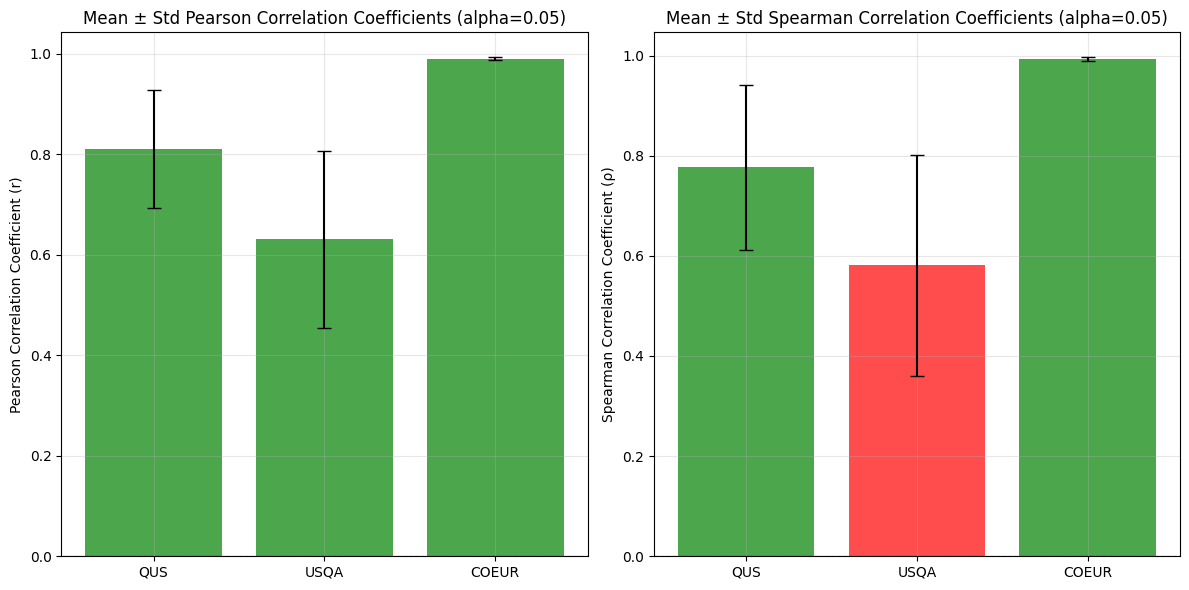

In [53]:
corrs = compute_correlations(
    dataset="alfred",
    experiment="epic",
    exhaustiveness_level="swise_coverage",
    exhaustiveness_type="ROUGE-2 Precision",
    cohesion_model="SpectralClustering",
    cohesion_type="Adjusted Mutual Info",
    lmbd=0.5
)
plot_correlations(corrs, alpha=0.05)

In [65]:
display_correlation_summary(
    dataset="alfred",
    experiment="epic",
    exhaustiveness_level="swise_coverage",
    exhaustiveness_type="ROUGE-2 Precision",
    cohesion_model="SpectralClustering",
    cohesion_type="Adjusted Mutual Info",
    lmbd=0.5
)

,Pearson,Spearman,Pearson p-value,Spearman p-value
Metric,,,,
COEUR,0.99 ± 0.00,0.99 ± 0.00,0.00 ± 0.00,0.00 ± 0.00
COH,0.93 ± 0.02,0.94 ± 0.02,0.00 ± 0.00,0.00 ± 0.00
EXH,1.00 ± 0.00,1.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00
QUS,0.81 ± 0.12,0.78 ± 0.16,0.00 ± 0.00,0.00 ± 0.01
USQA,0.63 ± 0.18,0.58 ± 0.22,0.02 ± 0.04,0.06 ± 0.14


### 2. Cohesion Noise 

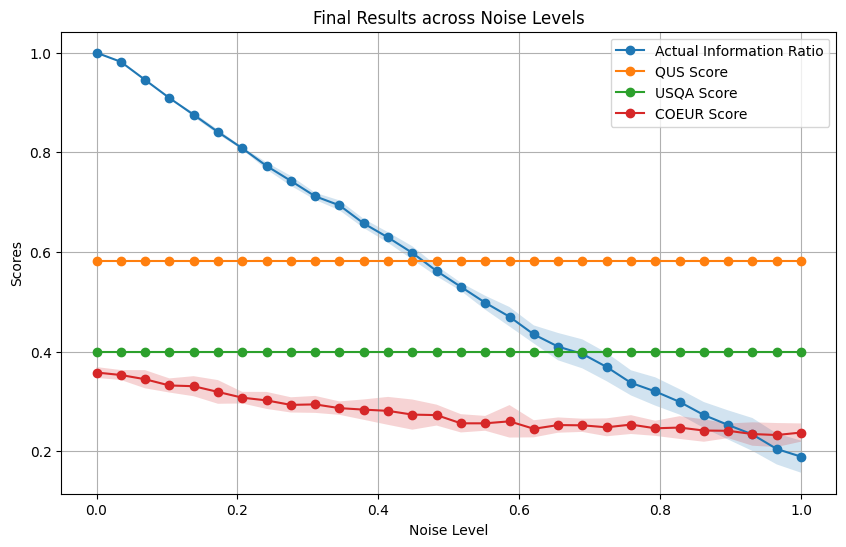

In [55]:
plot_COEUR_vs_QUS(
    dataset="alfred",
    experiment="story",
    exhaustiveness_level="swise_coverage",
    exhaustiveness_type="ROUGE-2 Precision",
    lmbd=0.5,
    cohesion_model="SpectralClustering",
    cohesion_type="Adjusted Mutual Info"
)

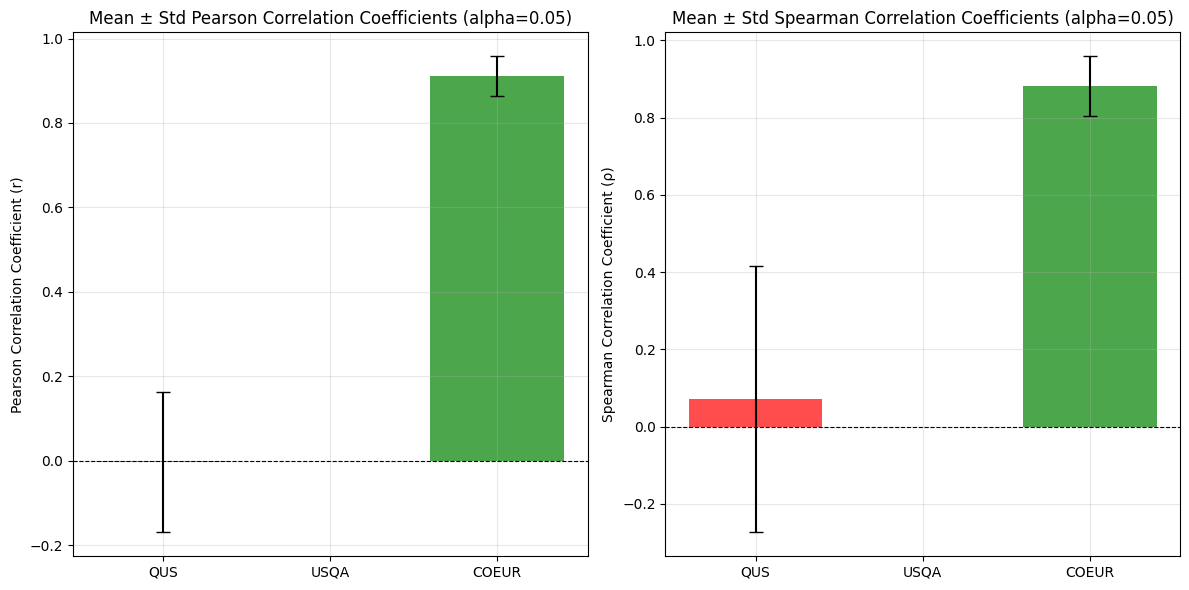

In [20]:
warnings.filterwarnings("ignore")
corrs = compute_correlations(
    dataset="trident",
    experiment="story/set_9_paper_results",
    exhaustiveness_level="swise_coverage",
    exhaustiveness_type="ROUGE-2 Precision",
    cohesion_model="SpectralClustering",
    cohesion_type="Adjusted Mutual Info",
    lmbd=0.5
)
plot_correlations(corrs, alpha=0.05)

In [21]:
warnings.filterwarnings("ignore")
display_correlation_summary(
    dataset="alfred",
    experiment="story/set_9_paper_results",
    exhaustiveness_level="swise_coverage",
    exhaustiveness_type="ROUGE-2 Precision",
    cohesion_model="AgglomerativeClustering",
    cohesion_type="Adjusted Mutual Info",
    lmbd=0.5
)

,Pearson,Spearman,Pearson p-value,Spearman p-value
Metric,,,,
COEUR,0.91 ± 0.03,0.89 ± 0.05,0.00 ± 0.00,0.00 ± 0.00
COH,0.91 ± 0.03,0.89 ± 0.05,0.00 ± 0.00,0.00 ± 0.00
EXH,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00
QUS,-0.37 ± 0.20,-0.50 ± 0.22,0.16 ± 0.24,0.09 ± 0.23
USQA,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00
